In [1]:
# Importing necessary libraries
# Data based on https://www.youtube.com/watch?v=k8yIvVFCguA

from stoneforge.pseudo_wells import anadrill_siliciclastic, color_codes, lithology_generator
from stoneforge.pseudo_wells.pseudo_tools import merge_lithology
from stoneforge.vis import plotwell
import pandas as pd
import numpy as np

In [2]:
# Empty function returns available facies

anadrill_siliciclastic()

0 shale
1 clean_sandstone with gas
2 clean_sandstone with oil
3 clean_sandstone with brine
4 feldspatic sandstone
5 unconsolidated sandstone with fresh water
6 organic shale
7 siltite
8 dirty sandstone with brine


In [3]:
markov_chain = np.array(
    [[0.93, 0.07, 0.00, 0.00], # Folhelho
    [0.02, 0.97, 0.01, 0.00], # Arenito
    [0.05, 0.10, 0.85, 0.00], # Arenito arcoseo
    [0.00, 0.00, 0.00, 0.00]] # Arenito sujo
    )

litho_ref = lithology_generator.simple(markov_chain,
    lithology_code  = [0,3,4,8],
    sampling = 1200,
    initial_state = 0
)

In [4]:
# Merging lithology codes 3 and 4 into a single code (e.g., 3)

result = merge_lithology(litho_ref)

In [35]:
# Define facies and sampling structure

well1,units1 = anadrill_siliciclastic(result, top = 800.0, bottom = 2000.0, step=0.30, random_state=False)

data_a = pd.DataFrame.from_dict(well1)
data_a

,DEPTH,GR,RES,NPHI,DEN,DT,CODE,ROCK,FLUID
0,800.3,111.271676,5.331493,0.277573,2.537572,104.979757,57,shale,none
1,800.6,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
2,800.9,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
3,801.2,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
4,801.5,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
...,...,...,...,...,...,...,...,...,...
1195,1158.8,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1196,1159.1,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1197,1159.4,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1198,1159.7,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine


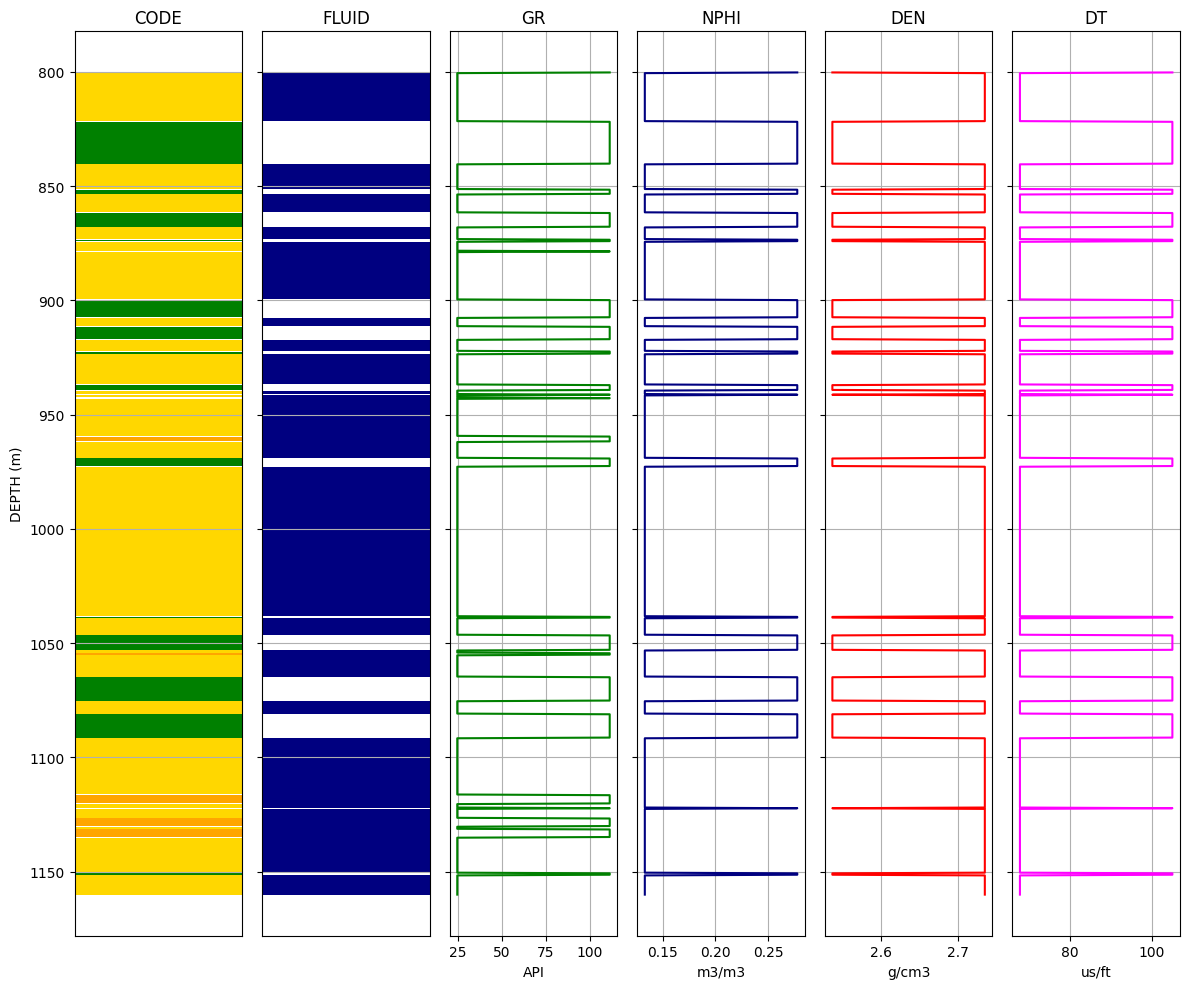

In [36]:
# Define curve and variables to plotting
# plotting data

curves = ['GR', 'NPHI', 'DEN', 'DT']
units2 = []
for c in curves:
    units2.append(units1[c])

color = ["green","navy","red","magenta"]

lito, fluid = color_codes()

pw = plotwell(data_a, "DEPTH", curves, color, units2)
pw.facies("CODE",lito)
pw.facies("FLUID",fluid)
pw.show()

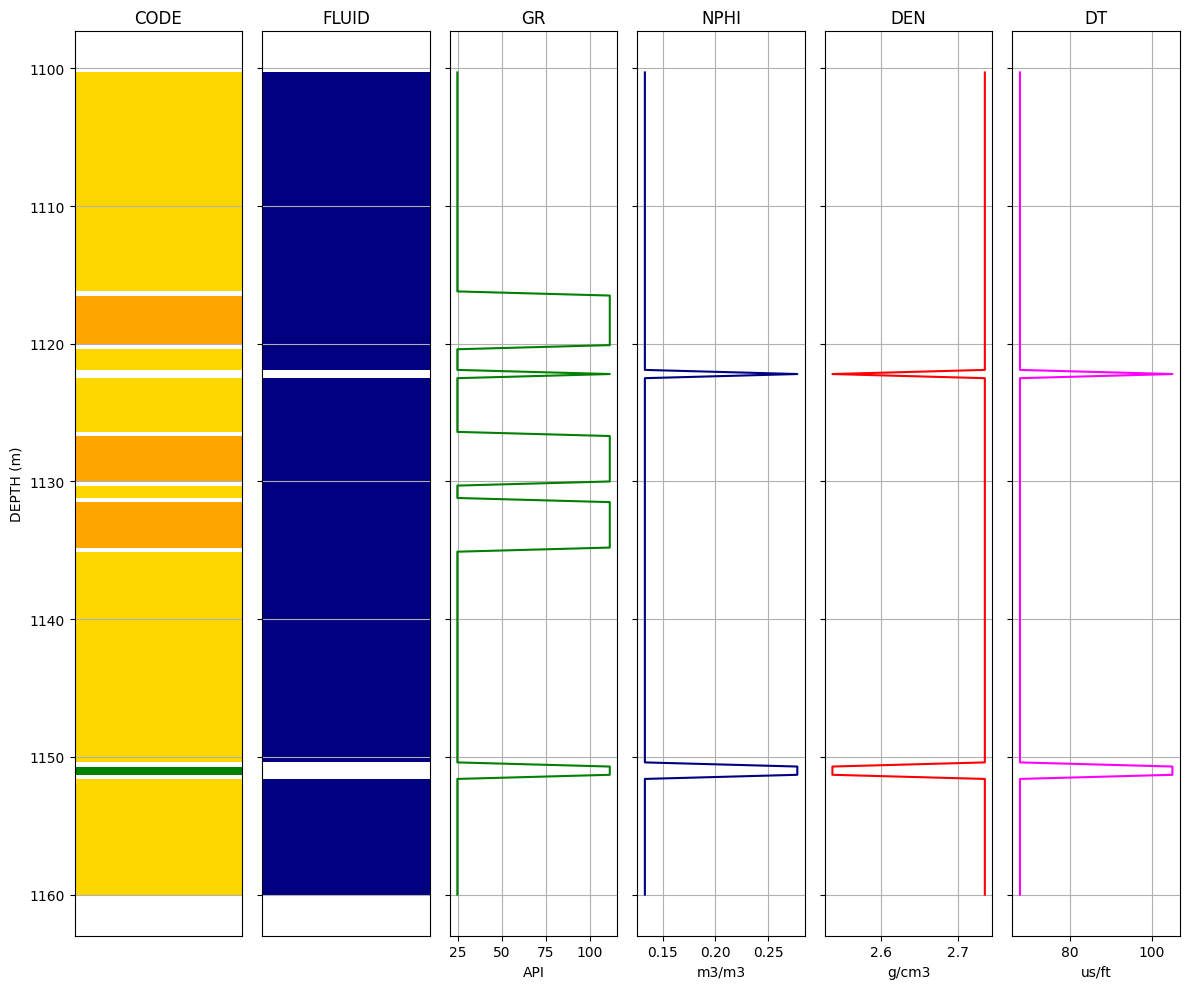

In [38]:

subd_data2 = data_a[(data_a['DEPTH'] >= 1100) & (data_a['DEPTH'] <= 1160)]
subd_data2

pw = plotwell(subd_data2, "DEPTH", curves, color, units2)
pw.facies("CODE",lito)
pw.facies("FLUID",fluid)
pw.show()

In [39]:
litho_ref2 = lithology_generator.simple(markov_chain,
    lithology_code  = [0,3,4,8],
    sampling = 1200,
    initial_state = 3,
    seed_value = 35
)

set(litho_ref2)

result_b = merge_lithology(litho_ref)

subd_data2

,DEPTH,GR,RES,NPHI,DEN,DT,CODE,ROCK,FLUID
1000,1100.3,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1001,1100.6,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1002,1100.9,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1003,1101.2,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1004,1101.5,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
...,...,...,...,...,...,...,...,...,...
1195,1158.8,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1196,1159.1,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1197,1159.4,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1198,1159.7,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine


In [ ]:
well3,units3 = anadrill_siliciclastic(result_b, top = 2000, bottom = 2600.0, step=0.10, random_state=False)
data3 = pd.DataFrame.from_dict(well3)
data3 = data3.iloc[1:]
data3

In [ ]:
curves = ['GR','NPHI', 'DEN', 'DT']
units4 = []
for c in curves:
    units4.append(units3[c])

color = ["green","navy","red","magenta"]

lito1, fluid1 = color_codes()

pw = plotwell(data3, "DEPTH", curves, color, units4)
pw.facies("CODE",lito1)
pw.facies("FLUID",fluid1)
pw.show()

In [ ]:
data_b = pd.concat([subd_data2, data3], ignore_index=True)
data_b

In [ ]:
curves = ['GR','NPHI', 'DEN', 'DT']
units5 = []
for c in curves:
    units5.append(units3[c])

color = ["green","navy","red","magenta"]

lito1, fluid1 = color_codes()

pw = plotwell(data_b, "DEPTH", curves, color, units5)
pw.facies("CODE", lito1)
pw.facies("FLUID", fluid1)
pw.show()

In [ ]:
DEPTHB = list(data_b['DEPTH'])
for i in range (len(DEPTHB)-1):
    print(DEPTHB[i+1] - DEPTHB[i])

In [ ]:
DEPTHA = list(data_a['DEPTH'])
for i in range (len(DEPTHA)-1):
    print(DEPTHA[i+1] - DEPTHA[i])